# Оценка рейтингов фильмов


**Датасет:** MovieLens 20M — https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset

**Постановка:** гибридное предсказание оценки `user → movie` (регрессия, `rating ∈ [0.5, 5.0]`).

**Метрики качества:** RMSE, MAE, R².

---

## 1. Введение и постановка задачи

### 1.1. Основные понятия

- **Рекомендательная система** — система, предсказывающая предпочтения пользователя
  (в нашем случае — оценку фильма).
- **Коллаборативная фильтрация (collaborative filtering)** — подход, использующий
  историю оценок множества пользователей: похожие пользователи похоже оценивают
  фильмы.
- **Контентная фильтрация (content-based)** — подход, опирающийся на признаки самих
  объектов (жанры, теги, год).
- **Гибридный подход** — объединяет коллаборативную и контентную информацию.
- **Эмбеддинги / латентные факторы (latent factors)** — обучаемые плотные векторы,
  кодирующие пользователей и фильмы в скрытом пространстве.
- **Матричная факторизация (Matrix Factorization)** — приближение матрицы оценок
  произведением матриц латентных факторов пользователей и фильмов.
- **Нейросетевая коллаборативная фильтрация (Neural CF / NeuMF)** — замена скалярного
  произведения эмбеддингов на нелинейную нейросеть (MLP).

### 1.2. Постановка задачи

Дана история оценок $(u, i, r)$, где $u$ — пользователь, $i$ — фильм,
$r \in \{0.5, 1.0, \dots, 5.0\}$ — оценка.

Требуется построить модель $\hat{r} = f(u, i, x_i)$, предсказывающую оценку, где
$x_i$ — контентные признаки фильма (жанры, genome-теги, год выпуска).

Это **задача регрессии**: целевая переменная — вещественная оценка в диапазоне
$[0.5, 5.0]$.

### 1.3. Подходы и методы решения

Рассматриваем последовательность моделей нарастающей сложности:

1. **Baseline** — глобальное среднее и модель смещений
   $\hat{r}_{ui} = \mu + b_u + b_i$ (точка отсчёта).
2. **Matrix Factorization (MF)** — эмбеддинги пользователя и фильма + смещения,
   скалярное произведение.
3. **NeuMF (Neural CF)** — конкатенация эмбеддингов user/movie, поданная в MLP.
4. **Hybrid** — эмбеддинги user/movie + отобранные контентные признаки фильма → MLP.

Сравнение этих методов между собой и с baseline — основная цель эксперимента.

### 1.4. Метрики оценки качества

- **RMSE** (Root Mean Squared Error) — основная метрика, сильнее штрафует крупные
  ошибки:
  $$\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{(u,i)} (r_{ui} - \hat{r}_{ui})^2}.$$
- **MAE** (Mean Absolute Error) — средняя абсолютная ошибка, устойчивее к выбросам:
  $$\mathrm{MAE} = \frac{1}{N}\sum_{(u,i)} |r_{ui} - \hat{r}_{ui}|.$$
- **R²** (коэффициент детерминации) — доля объяснённой дисперсии целевой переменной.

Качество измеряем на отложенной (test) выборке, не участвующей в обучении и подборе
гиперпараметров.

## 2. Импорт библиотек и конфигурация

In [2]:
from pathlib import Path

# Работа с табличными данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt

# PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Метрики качества
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# --- Конфигурация эксперимента ---
# Собираем все настройки в одном месте, чтобы исследование было
# воспроизводимым и его легко было корректировать.

SEED = 42  # фиксированное зерно ГСЧ для воспроизводимости результатов

# Пути к данным
DATA_DIR = Path("data")

# Параметры формирования подвыборки (раздел 3).
# Полный rating.csv содержит ~20 млн оценок, что избыточно для учебного
# стенда. Оставляем только "активных" пользователей и ограничиваем общий
# объём выборки, чтобы ускорить обучение и подбор гиперпараметров.
MIN_USER_RATINGS = 50         # минимальное число оценок у "активного" пользователя
TARGET_RATINGS = 2_000_000    # целевой объём подвыборки (порядка 1–2 млн оценок)

# Фиксируем зерно для numpy и torch
np.random.seed(SEED)
torch.manual_seed(SEED)

# Выбираем устройство: GPU при наличии, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Единый стиль графиков
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

print(f"Версия PyTorch: {torch.__version__}")
print(f"Устройство для обучения: {device}")

Версия PyTorch: 2.13.0.dev20260507+cu130
Устройство для обучения: cuda


## 3. Загрузка данных

Состав датасета MovieLens 20M:

| Файл | Содержание | Используем |
|------|-----------|-----------|
| `rating.csv` | userId, movieId, rating, timestamp (≈20 млн строк) | да — целевые оценки |
| `movie.csv` | movieId, title, genres | да — жанры, год из названия |
| `genome_scores.csv` | movieId, tagId, relevance (≈1128 тегов) | да — контентные признаки |
| `genome_tags.csv` | tagId, tag | да — расшифровка тегов |
| `tag.csv` | пользовательские текстовые теги | нет (опционально) |
| `link.csv` | связи с IMDb/TMDb | нет |

Из-за объёма `rating.csv` (~690 МБ) работаем с **подвыборкой активных
пользователей** (~1–2 млн оценок).

In [4]:
# --- Загрузка справочников ---

# Описание фильмов: идентификатор, название (с годом), список жанров
movies = pd.read_csv(DATA_DIR / "movie.csv")

# Genome-теги: матрица релевантности "фильм × тег" (~11 млн строк).
# Указываем компактные типы, чтобы снизить расход памяти.
genome_scores = pd.read_csv(
    DATA_DIR / "genome_scores.csv",
    dtype={"movieId": "int32", "tagId": "int16", "relevance": "float32"},
)

# Расшифровка genome-тегов: tagId -> текстовое название тега
genome_tags = pd.read_csv(DATA_DIR / "genome_tags.csv")

print(f"movies:        {movies.shape}")
print(f"genome_scores: {genome_scores.shape}")
print(f"genome_tags:   {genome_tags.shape}")
movies.head()

movies:        (27278, 3)
genome_scores: (11709768, 3)
genome_tags:   (1128, 2)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
# --- Загрузка оценок с подвыборкой активных пользователей ---
# rating.csv — самый большой файл (~20 млн строк, 690 МБ). Чтобы стенд
# оставался лёгким, формируем подвыборку: оставляем только активных
# пользователей и ограничиваем общий объём до ~TARGET_RATINGS оценок.

# Загружаем оценки в компактных типах
ratings_full = pd.read_csv(
    DATA_DIR / "rating.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
    parse_dates=["timestamp"],
)
print(f"Полный размер rating.csv: {len(ratings_full):,} оценок, "
      f"{ratings_full['userId'].nunique():,} пользователей")

# Шаг 1. Считаем число оценок на пользователя и отбираем активных:
# пользователи с малым числом оценок дают мало информации и осложняют
# обучение эмбеддингов.
user_counts = ratings_full["userId"].value_counts()
active_users = user_counts.index[user_counts >= MIN_USER_RATINGS].to_numpy()
print(f"Активных пользователей (>= {MIN_USER_RATINGS} оценок): {len(active_users):,}")

# Шаг 2. Случайно набираем активных пользователей, пока суммарное число
# их оценок не достигнет целевого объёма подвыборки. Это даёт выборку
# нужного размера без смещения по конкретным пользователям.
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(active_users)
cumulative = np.cumsum(user_counts.loc[shuffled].to_numpy())
n_take = int(np.searchsorted(cumulative, TARGET_RATINGS)) + 1
selected_users = set(shuffled[:n_take].tolist())

# Шаг 3. Оставляем оценки только выбранных пользователей и освобождаем память.
ratings = ratings_full[ratings_full["userId"].isin(selected_users)].reset_index(drop=True)
del ratings_full

print(f"\nИтоговая подвыборка: {len(ratings):,} оценок, "
      f"{ratings['userId'].nunique():,} пользователей, "
      f"{ratings['movieId'].nunique():,} фильмов")
ratings.head()

Полный размер rating.csv: 20,000,263 оценок, 138,493 пользователей
Активных пользователей (>= 50 оценок): 85,307

Итоговая подвыборка: 2,000,277 оценок, 9,289 пользователей, 17,776 фильмов


,userId,movieId,rating,timestamp
0,19,1,5.0,1997-02-05 21:03:48
1,19,3,4.0,1997-02-05 21:04:44
2,19,6,5.0,1997-02-05 21:04:44
3,19,7,5.0,1997-02-05 21:04:44
4,19,14,4.0,1997-02-05 21:05:23


## 4. Разведочный (описательный) анализ данных — EDA

Цель — понять структуру и качество данных: распределение оценок, активность
пользователей и фильмов, разреженность матрицы, временные и жанровые эффекты,
характер genome-признаков. Выводы EDA определяют решения по предобработке и
выбору моделей.

In [6]:
# --- Базовые статистики подвыборки ---
# Оцениваем масштаб задачи и разреженность матрицы оценок: эти величины
# объясняют, почему "в лоб" заполнить матрицу user × movie невозможно.

n_ratings = len(ratings)
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()

# Разреженность = доля реально проставленных оценок от всех возможных пар
sparsity = n_ratings / (n_users * n_movies)

print(f"Число оценок:        {n_ratings:,}")
print(f"Уникальных юзеров:   {n_users:,}")
print(f"Уникальных фильмов:  {n_movies:,}")
print(f"Заполнено пар user×movie: {sparsity:.4%} "
      f"(разреженность матрицы — {1 - sparsity:.4%})")
print("\nОписательная статистика по оценкам:")
ratings["rating"].describe()

Число оценок:        2,000,277
Уникальных юзеров:   9,289
Уникальных фильмов:  17,776
Заполнено пар user×movie: 1.2114% (разреженность матрицы — 98.7886%)

Описательная статистика по оценкам:


count    2.000277e+06
mean     3.519074e+00
std      1.044290e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

**Вывод.** Подвыборка включает 2 млн оценок от 9 289 пользователей по 17 776 фильмам.
Заполнено лишь ≈1,2 % всех возможных пар «пользователь × фильм» (разреженность ≈98,8 %),
поэтому напрямую восстановить матрицу оценок невозможно — необходимы модели со скрытыми
представлениями (эмбеддингами). Средняя оценка составляет 3,52 при медиане 3,5, то есть
пользователи в среднем оценивают фильмы выше середины шкалы.

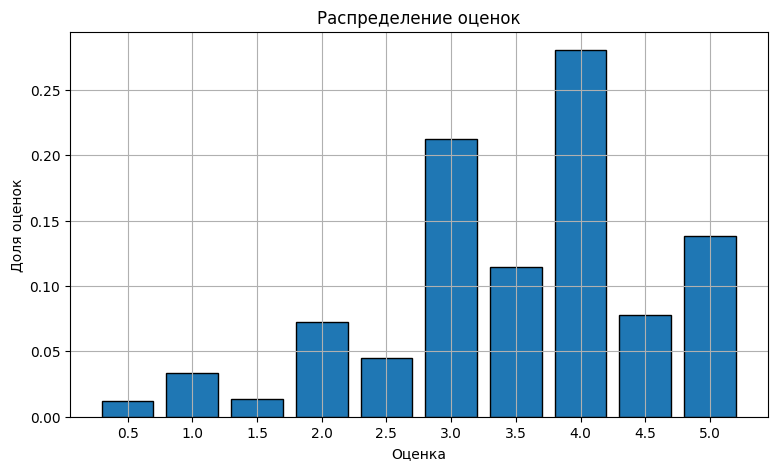

Доли значений оценок:
rating
0.5     1.17 %
1.0     3.37 %
1.5     1.35 %
2.0     7.28 %
2.5     4.49 %
3.0    21.22 %
3.5    11.44 %
4.0    28.04 %
4.5     7.81 %
5.0    13.82 %
Name: proportion, dtype: object

Средняя оценка: 3.519
Медианная оценка: 3.5


In [7]:
# --- Распределение оценок ---
# Оценки дискретны (шаг 0.5 в диапазоне 0.5–5.0). Смотрим, как часто
# встречается каждое значение: это показывает смещение пользователей
# в сторону высоких оценок и пригодится при выборе baseline.

rating_counts = ratings["rating"].value_counts(normalize=True).sort_index()

plt.bar(rating_counts.index, rating_counts.values, width=0.4, edgecolor="black")
plt.xlabel("Оценка")
plt.ylabel("Доля оценок")
plt.title("Распределение оценок")
plt.xticks(np.arange(0.5, 5.5, 0.5))
plt.show()

print("Доли значений оценок:")
print((rating_counts * 100).round(2).astype(str) + " %")
print(f"\nСредняя оценка: {ratings['rating'].mean():.3f}")
print(f"Медианная оценка: {ratings['rating'].median():.1f}")

**Вывод.** Распределение оценок смещено в сторону высоких значений: самые частые оценки —
4,0 (28 %) и 3,0 (21 %), тогда как на низкие оценки (≤2,0) приходится менее 13 %. Заметно,
что целые оценки выставляются чаще полуцелых (особенность поведения пользователей). Такой
дисбаланс означает, что даже тривиальный прогноз «средним» (≈3,5) даёт умеренную ошибку —
это и задаёт нижнюю планку качества для baseline.

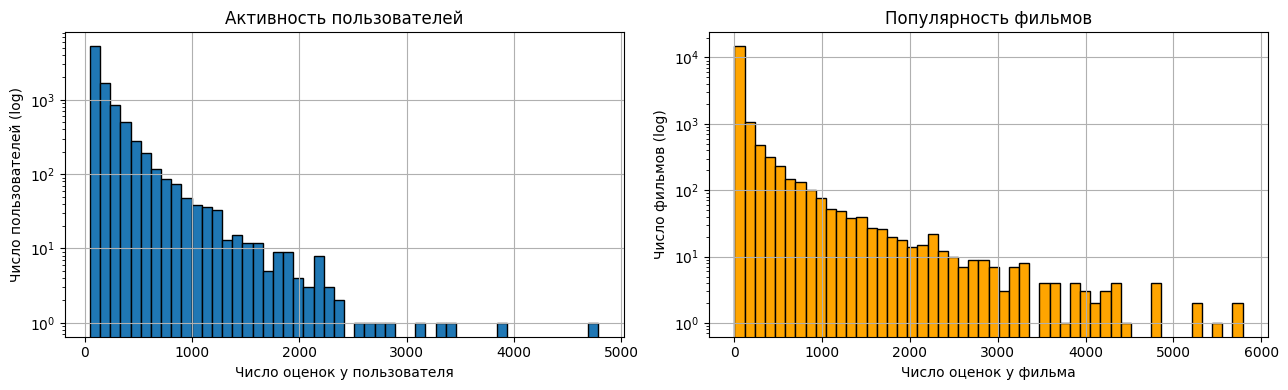

Оценок на пользователя:
count    9289.0
mean      215.3
std       265.9
min        50.0
25%        75.0
50%       124.0
75%       243.0
max      4785.0
dtype: float64

Оценок на фильм:
count    17776.0
mean       112.5
std        356.6
min          1.0
25%          2.0
50%          9.0
75%         54.0
max       5789.0
dtype: float64


In [8]:
# --- Активность пользователей и популярность фильмов ---
# Проверяем гипотезу о "длинном хвосте": немного очень активных
# пользователей и популярных фильмов и много редких. Это ключевой фактор
# для разреженности и проблемы холодного старта.

ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings_per_user, bins=50, edgecolor="black")
axes[0].set_yscale("log")  # лог-шкала: иначе хвост не виден
axes[0].set_xlabel("Число оценок у пользователя")
axes[0].set_ylabel("Число пользователей (log)")
axes[0].set_title("Активность пользователей")

axes[1].hist(ratings_per_movie, bins=50, edgecolor="black", color="orange")
axes[1].set_yscale("log")
axes[1].set_xlabel("Число оценок у фильма")
axes[1].set_ylabel("Число фильмов (log)")
axes[1].set_title("Популярность фильмов")

plt.tight_layout()
plt.show()

print("Оценок на пользователя:")
print(ratings_per_user.describe().round(1))
print("\nОценок на фильм:")
print(ratings_per_movie.describe().round(1))

**Вывод.** Подтверждается эффект «длинного хвоста». У пользователей медиана составляет
124 оценки (минимум 50 — следствие фильтра активности), тогда как у фильмов половина имеет
менее 9 оценок, а четверть — не более двух. Малое число оценок у большинства фильмов
порождает проблему холодного старта и обосновывает дальнейшую фильтрацию редко оцениваемых
фильмов на этапе предобработки.

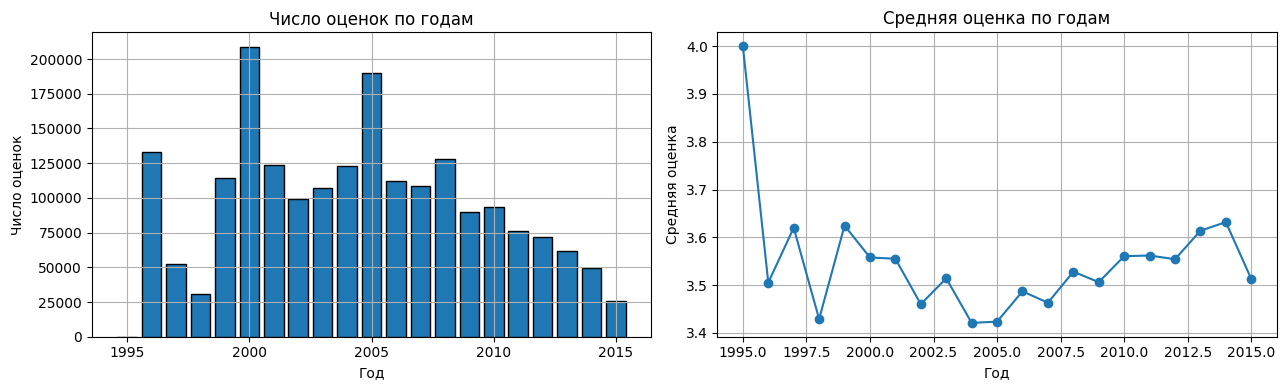

Период данных: 1995 – 2015


,count,mean
year,,
1995,1,4.000
1996,132930,3.505
1997,52724,3.620
1998,31100,3.429
1999,114018,3.625
2000,208785,3.558
2001,123789,3.555
2002,99271,3.460
2003,107302,3.514


In [9]:
# --- Временной разрез ---
# Смотрим, как менялись активность (число оценок) и средняя оценка по
# годам. Это показывает, есть ли временной сдвиг в данных, который стоит
# учитывать при разбиении train/test.

ratings["year"] = ratings["timestamp"].dt.year
year_stats = ratings.groupby("year")["rating"].agg(count="size", mean="mean")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(year_stats.index, year_stats["count"], edgecolor="black")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("Число оценок")
axes[0].set_title("Число оценок по годам")

axes[1].plot(year_stats.index, year_stats["mean"], marker="o")
axes[1].set_xlabel("Год")
axes[1].set_ylabel("Средняя оценка")
axes[1].set_title("Средняя оценка по годам")

plt.tight_layout()
plt.show()

print(f"Период данных: {ratings['year'].min()} – {ratings['year'].max()}")
year_stats.round(3)

**Вывод.** Данные охватывают период 1995–2015 гг. Средняя оценка по годам остаётся
стабильной (колеблется в узком диапазоне ≈3,42–3,63) без выраженного тренда, а объём оценок
распределён неравномерно (заметные пики в 2000 и 2005 гг.). Отсутствие временного дрейфа
целевой переменной позволяет использовать случайное разбиение на train/val/test, не прибегая
к строгому разбиению по времени.

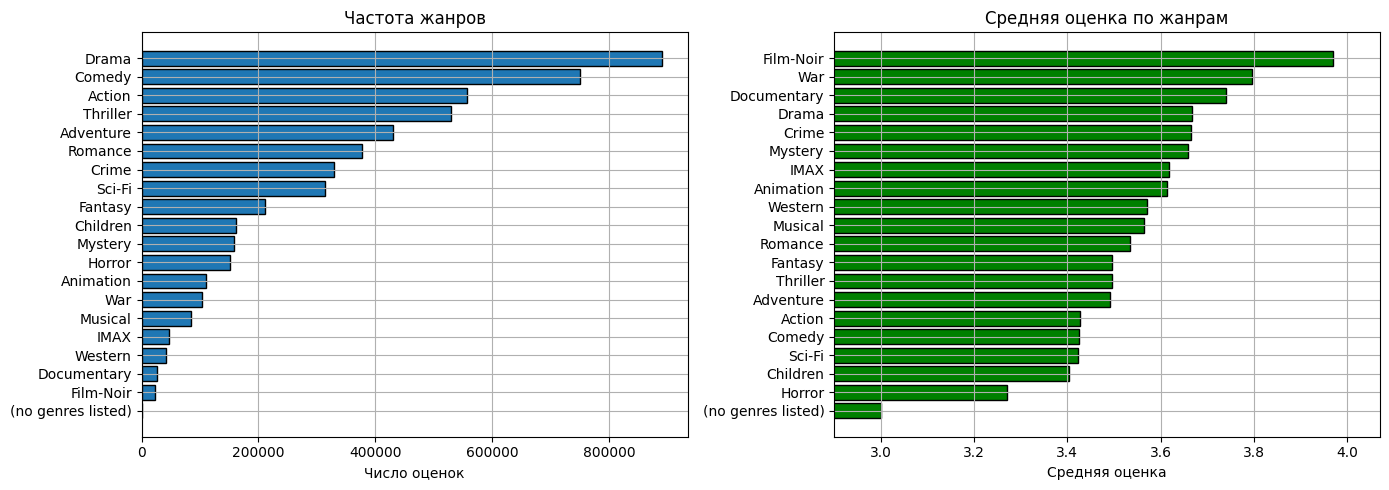

,count,mean
genre,,
Drama,889654,3.668
Comedy,750192,3.424
Action,556392,3.428
Thriller,529899,3.495
Adventure,429913,3.493
Romance,376297,3.534
Crime,329913,3.666
Sci-Fi,314134,3.423
Fantasy,210915,3.496


In [10]:
# --- Анализ жанров ---
# Жанр — первый кандидат в контентные признаки. Проверяем, насколько
# часто встречается каждый жанр и различается ли по нему средняя оценка
# (если различается — жанр несёт полезный сигнал для модели).

# Присоединяем жанры фильмов к оценкам и разворачиваем список жанров
# ("Adventure|Comedy" -> две строки) для подсчёта по каждому жанру.
ratings_genres = (
    ratings.merge(movies[["movieId", "genres"]], on="movieId", how="left")
    .assign(genre=lambda d: d["genres"].str.split("|"))
    .explode("genre")
)

genre_stats = (
    ratings_genres.groupby("genre")["rating"]
    .agg(count="size", mean="mean")
    .sort_values("count", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(genre_stats.index, genre_stats["count"], edgecolor="black")
axes[0].invert_yaxis()
axes[0].set_xlabel("Число оценок")
axes[0].set_title("Частота жанров")

# Средняя оценка по жанру: сортируем, чтобы увидеть "любимые" и "нелюбимые"
genre_by_mean = genre_stats.sort_values("mean")
axes[1].barh(genre_by_mean.index, genre_by_mean["mean"], edgecolor="black", color="green")
axes[1].set_xlabel("Средняя оценка")
axes[1].set_xlim(genre_by_mean["mean"].min() - 0.1, genre_by_mean["mean"].max() + 0.1)
axes[1].set_title("Средняя оценка по жанрам")

plt.tight_layout()
plt.show()

genre_stats.round(3)

**Вывод.** Самые массовые жанры — Drama, Comedy и Action. При этом средняя оценка заметно
зависит от жанра: выше всего оцениваются Film-Noir (3,97), War (3,80) и Documentary (3,74),
ниже всего — Horror (3,27) и Children (3,40). Разброс средних оценок между жанрами достигает
≈0,7 балла, следовательно жанр несёт полезный сигнал и оправдан как контентный признак
гибридной модели.

Всего genome-тегов: 1128


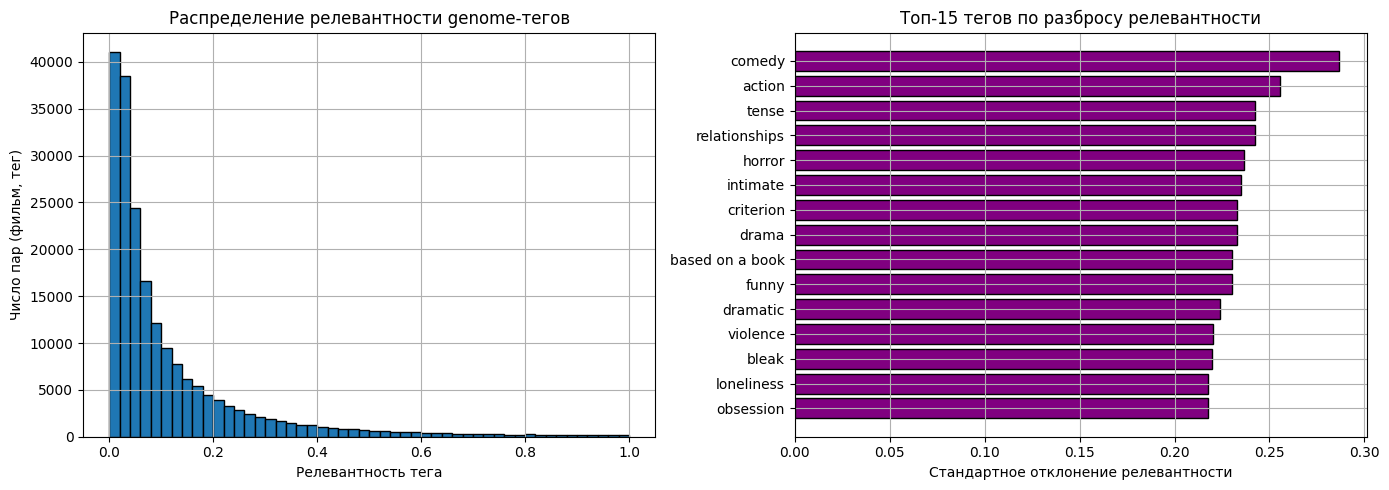

,tag,mean,std
229,comedy,0.251,0.287
18,action,0.265,0.256
1019,tense,0.224,0.243
845,relationships,0.283,0.242
521,horror,0.112,0.237
556,intimate,0.249,0.235
269,criterion,0.388,0.233
322,drama,0.361,0.233
106,based on a book,0.274,0.230
416,funny,0.195,0.230


In [11]:
# --- Обзор genome-признаков ---
# genome_scores задаёт для каждого фильма вектор релевантности по ~1128
# тегам (значения 0..1). Это богатый источник контентных признаков, но
# их много — оценим их характер, чтобы понять, какие пригодны для отбора.

# Статистика релевантности по каждому тегу: средняя и разброс (std).
# Высокий std означает, что тег хорошо разделяет фильмы между собой.
tag_stats = (
    genome_scores.groupby("tagId")["relevance"]
    .agg(mean="mean", std="std")
    .merge(genome_tags, on="tagId")
)
print(f"Всего genome-тегов: {len(tag_stats)}")

# Распределение релевантности (по случайной подвыборке строк для скорости)
sample = genome_scores["relevance"].sample(200_000, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample, bins=50, edgecolor="black")
axes[0].set_xlabel("Релевантность тега")
axes[0].set_ylabel("Число пар (фильм, тег)")
axes[0].set_title("Распределение релевантности genome-тегов")

# Топ-15 наиболее "различающих" тегов (по std) — кандидаты в признаки
top_var = tag_stats.sort_values("std", ascending=False).head(15)
axes[1].barh(top_var["tag"], top_var["std"], edgecolor="black", color="purple")
axes[1].invert_yaxis()
axes[1].set_xlabel("Стандартное отклонение релевантности")
axes[1].set_title("Топ-15 тегов по разбросу релевантности")

plt.tight_layout()
plt.show()

top_var[["tag", "mean", "std"]].round(3)

**Вывод.** Распределение genome-релевантности сильно скошено к нулю: для большинства пар
«фильм–тег» тег нерелевантен. Наибольший разброс (std) имеют как жанровые теги (comedy,
action, horror, drama), так и тематические (tense, relationships, obsession) — именно они
лучше всего различают фильмы. Поскольку из 1128 тегов информативна лишь часть, перед
обучением гибридной модели потребуется отбор значимых признаков (раздел 6).

### Выводы по EDA

Проведённый разведочный анализ позволяет сформулировать ключевые наблюдения и решения для
последующих этапов работы:

1. **Разреженность.** Заполнено лишь ≈1,2 % пар «пользователь × фильм», поэтому задача
   решается моделями со скрытыми представлениями (эмбеддингами), а не прямым восстановлением
   матрицы оценок.
2. **Дисбаланс оценок.** Оценки смещены в сторону высоких значений (среднее ≈3,52, пик на 4,0).
   Прогноз «средним» задаёт нижнюю планку качества, относительно которой оцениваются модели.
3. **Длинный хвост.** Большинство фильмов имеют мало оценок (медиана 9), что создаёт проблему
   холодного старта и обосновывает фильтрацию редких фильмов на этапе предобработки.
4. **Стабильность во времени.** Средняя оценка по годам не имеет выраженного тренда —
   допустимо случайное разбиение на обучающую, валидационную и тестовую выборки.
5. **Информативность контента.** Жанры (разброс средних оценок до ≈0,7 балла) и genome-теги
   несут полезный сигнал, что подтверждает целесообразность гибридного подхода. При этом из
   1128 genome-тегов информативна лишь часть — необходим отбор значимых признаков.

Эти выводы определяют дальнейшие шаги: фильтрацию и переиндексацию данных, формирование
контентных признаков, отбор значимых признаков и построение моделей нарастающей сложности.

## 5. Предобработка данных

План и обоснование шагов предобработки перед обучением.

In [12]:
# Фильтрация неактивных пользователей и редко оцениваемых фильмов
# по порогам из конфигурации (борьба с разреженностью и шумом).


In [13]:
# Переиндексация идентификаторов: userId/movieId -> непрерывные индексы [0..N)
# для слоёв эмбеддингов; сохранение словарей соответствия.


In [14]:
# Формирование контентных признаков фильма:
# - one-hot кодирование жанров;
# - извлечение года из названия (regex) и нормализация;
# - матрица genome-релевантности (movie x tag).


In [15]:
# Разбиение на train / val / test (по времени либо стратифицированно по пользователю).
# Контроль утечек; фиксация cold-start случаев (новые user/movie в test).


## 6. Отбор значимых признаков

Выполнение требования задания «отбор значимых признаков». Применяется к контентным
признакам фильма (жанры, ~1128 genome-тегов, год). Цель — оставить наиболее
информативные признаки, снизить размерность и шум перед подачей в гибридную модель.

In [16]:
# Удаление низковариативных признаков (VarianceThreshold).


In [17]:
# Оценка значимости признаков относительно целевой переменной:
# корреляция / mutual information; отбор top-K genome-тегов.


In [18]:
# Визуализация важности признаков (топ по значимости) и фиксация
# финального набора контентных признаков для гибридной модели.


### Итоговый набор признаков

_(Список отобранных признаков и краткое обоснование выбора.)_

## 7. Проектирование и реализация исследовательского стенда

Единый стенд обеспечивает честное сравнение моделей: общий формат данных
(`Dataset`/`DataLoader`), единый цикл обучения с ранней остановкой, единые функции
метрик и общий интерфейс оценки. Все модели обучаются и оцениваются одинаково.

In [19]:
# Класс Dataset и DataLoader: батчи (user_idx, movie_idx, content_features) -> rating.


In [20]:
# Функции метрик: RMSE, MAE, R² (единые для всех моделей).


In [21]:
# Универсальные процедуры train_model() и evaluate_model():
# цикл по эпохам, оптимизатор, логирование loss/RMSE, early stopping,
# сохранение кривых обучения.


In [22]:
# Baseline-предсказатели как точка отсчёта:
# - глобальное среднее (mu);
# - модель смещений (mu + b_user + b_movie).


## 8. Нейросетевые модели

Три архитектуры нарастающей сложности. Различие — в том, как используется информация:
от чистой коллаборативной (MF, NeuMF) к гибридной (контент + взаимодействия).

In [23]:
# Модель 1 — Matrix Factorization:
# эмбеддинги user и movie + смещения b_u, b_i; предсказание = dot(p_u, q_i) + b_u + b_i + mu.


In [24]:
# Модель 2 — NeuMF (Neural Collaborative Filtering):
# конкатенация эмбеддингов user и movie -> MLP (несколько слоёв с нелинейностью) -> оценка.


In [25]:
# Модель 3 — Hybrid:
# эмбеддинги user/movie + отобранные контентные признаки фильма (раздел 6) -> MLP -> оценка.


## 9. Подбор гиперпараметров

Небольшой поиск (grid/random search) по валидационной выборке. Пространство поиска:
размер эмбеддинга, learning rate, число и ширина скрытых слоёв, dropout, weight decay.
Для каждой модели выбираем лучшую конфигурацию по RMSE на валидации.

In [26]:
# Цикл подбора гиперпараметров для каждой модели:
# перебор конфигураций, обучение на train, оценка на val,
# сводная таблица результатов и выбор лучших гиперпараметров.


## 10. Обучение финальных моделей

In [27]:
# Обучение baseline и трёх моделей с лучшими гиперпараметрами на train;
# сохранение истории обучения (loss/RMSE по эпохам).


In [28]:
# Графики сходимости (train/val) для каждой модели.


## 11. Оценка качества и сравнительный анализ

Финальное сравнение моделей проводится на отложенной test-выборке, не участвовавшей
ни в обучении, ни в подборе гиперпараметров.

In [29]:
# Сводная таблица метрик (RMSE / MAE / R²) по всем моделям и baseline.


In [30]:
# Столбчатые диаграммы сравнения метрик между моделями.


In [31]:
# Анализ остатков лучшей модели: распределение ошибок,
# ошибки по сегментам (активные/неактивные пользователи, популярные/редкие фильмы).


## 12. Выбор лучшей модели и анализ результатов

_(Обоснование выбора лучшей модели по метрикам; интерпретация: что дали контентные
признаки и их отбор, на каких объектах модели ошибаются, проблема cold-start.)_

## 13. Выводы

_(Итоги по решению задачи; сравнение методов; ограничения подхода и направления
дальнейшего развития.)_